In [1]:
# Importing Data
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint
import numpy as np
SKIP_ROWS = 11
files = ["p1.csv", "p2.csv", "p3.csv", "p4.csv"]

df = pd.concat(
    [
        pd.read_csv(file, skiprows=SKIP_ROWS, usecols=[0, 1])
        for file in files
    ],
    ignore_index=True
)

df = df.dropna(how="all")
df.iloc[:, 0] = df.iloc[:, 0]*10
df.iloc[:, 1] = df.iloc[:, 1]*10
len(df)


700

In [2]:
# Adding Columns
from pandas.api.indexers import FixedForwardWindowIndexer
DISTANCE_TO_CAMERA = 5050 # mm
BACKGROUND = 20
FULL_ROTATION = 300_000
N = len(df)
w = N // 4

def divergence(x):
    return 1000*(x.max() - x.min()) / DISTANCE_TO_CAMERA
    

# Wrap data
steps = np.linspace(0,FULL_ROTATION,len(df))
df["step"] = steps

dfb = pd.concat([df, df.head(w)], ignore_index=True)
indexer = FixedForwardWindowIndexer(window_size=w)
# Add standard devs
dfb["stdX"] = dfb.iloc[:, 0].rolling(window=indexer).std()
dfb["stdY"] = dfb.iloc[:, 1].rolling(window=indexer).std()
dfb["s"] = (dfb["stdX"]**2 + dfb["stdY"]**2)**0.5
dfb["divergence"] = dfb.iloc[:, 1].rolling(window=indexer).apply(divergence)


dfb.dropna(inplace=True)
dfb = dfb.iloc[:-1]

min_row = dfb["divergence"].idxmin()
dfb.iloc[min_row]

optimum_window = dfb.iloc[min_row:min_row+w]


# Results


s: 648.31
estimated_div_x: 418.26 mrad
estimated_div_y: 89.76 mrad
estimated_div: 398.257426


188412 CW
111588 CW




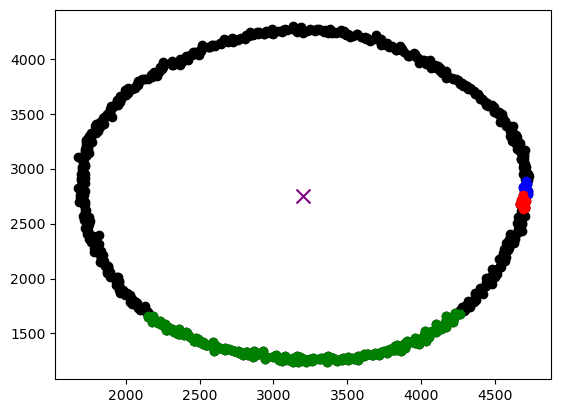

In [3]:
#Plotting
NODE_LENGTH = 10
plt.scatter(dfb.iloc[:, 0],dfb.iloc[:, 1], color="k")
plt.scatter(optimum_window.iloc[:, 0],optimum_window.iloc[:, 1], color="green")
plt.scatter(dfb.iloc[:, 0][:NODE_LENGTH],dfb.iloc[:, 1][:NODE_LENGTH], color="blue")
plt.scatter(dfb.iloc[:, 0][-NODE_LENGTH:], dfb.iloc[:, 1][-NODE_LENGTH:], color="red")
plt.scatter(dfb.iloc[:, 0].mean(), dfb.iloc[:, 1].mean(), color="purple", marker="x", s=100)

optimal_step = optimum_window.iloc[0]["step"]
optimal_s = optimum_window.iloc[0]["s"]
estimated_div_x = divergence(  optimum_window.iloc[:, 0]   )
estimated_div_y = divergence(  optimum_window.iloc[:, 1]   )

print(F"""
s: {optimal_s:.2f}
estimated_div_x: {estimated_div_x:.2f} mrad
estimated_div_y: {estimated_div_y:.2f} mrad
estimated_div: { (((estimated_div_x+estimated_div_x)/2) - BACKGROUND) :2f}
""")

print(F"""
{optimal_step:.0f} CW
{(FULL_ROTATION - optimal_step):.0f} CW

""")